In [15]:
import os
import sys
import time
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import umap
import umap.plot
from tqdm.auto import tqdm
from pathlib import Path
from sklearn.model_selection import train_test_split

# 현재 노트북이 있는 경로 기준으로 프로젝트 루트(recsys) 경로 계산
current_dir = (
    os.path.dirname(os.path.abspath(__file__))
    if "__file__" in globals()
    else os.getcwd()
)
project_root = os.path.abspath(os.path.join(current_dir, ".."))

# recsys 폴더를 sys.path에 추가
if project_root not in sys.path:
    sys.path.append(project_root)

from setup_env import setup_env

root_dir = setup_env()

from utils.dataset.config import DatasetPath
from models.lightgcn.lightgcn import LightGCN
from models.lightgcn.metrics import compute_bpr_loss, get_metrics

[INFO] Font applied: NanumGothic


# Load Dataset

In [16]:
# 데이터셋 경로
dataset_dir = Path(root_dir).joinpath("data/dataset")
paths = DatasetPath(root_dir=dataset_dir, dataset_name="fashion")

df_user_logs = pd.read_parquet(paths.user_logs_path)

# Preprocess

In [17]:
# LightGCN 학습을 위한 user-item 상호작용 데이터 생성
df_train = df_user_logs[["user_id", "item_id"]].drop_duplicates(ignore_index=True)
df_train.head()

,user_id,item_id
0,1,3583
1,1,9638
2,1,1679
3,1,6133
4,1,113


# Train

In [18]:
# -----------------------------------------------
# LightGCN 학습 및 User, Item Embedding 추출 코드
# -----------------------------------------------


def train(df: pd.DataFrame, save_path: Path, params: dict, device: str = "cpu") -> None:
    """
    :param df: 학습 데이터
    :param save_path: 학습 결과 파일 저장 경로 (임베딩 벡터, 모델 Loss 등)
    :param params: 모델 파라미터
    :param device: 텐서를 저장할 장치 (CPU/GPU)
    :return:
    """

    # 모델 파라미터
    EPOCHS = params["epochs"]
    BATCH_SIZE = params["batch_size"]
    n_layers = params["n_layers"]
    latent_dim = params["latent_dim"]
    DECAY = params["decay"]
    TOP_K = params["top_k"]

    # 모델 및 옵티마이저 초기화
    model = LightGCN(data=df, n_layers=n_layers, latent_dim=latent_dim)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.02)
    model = model.to(device)

    # 학습 로그 저장용 리스트
    loss_list_epoch = []
    mf_loss_list_epoch = []
    reg_loss_list_epoch = []

    recall_list = []
    precision_list = []

    train_time_list = []
    eval_time_list = []

    # Train/Test 데이터 분할 (평가용 20%)
    _, test = train_test_split(df.values, test_size=0.2, random_state=42)
    df_test = pd.DataFrame(test, columns=df.columns)

    print(f"Training start - {device}")
    for epoch in tqdm(range(EPOCHS), desc="Training..", dynamic_ncols=True):
        # 하나의 Epoch 내 배치 수 계산
        n_batch = int(df.shape[0] / BATCH_SIZE)
        print(f"Batch size: {n_batch}")

        # 배치별 Loss
        mf_loss_list = []
        reg_loss_list = []
        final_loss_list = []

        train_start_time = time.time()
        model.train()

        # 배치 학습 루프
        for _ in range(n_batch):

            # Gradient 초기화
            optimizer.zero_grad()

            # User, Positive Item, Negative Item 샘플링
            users, pos_items, neg_items = model.load_data(batch_size=BATCH_SIZE)

            # Forward (최종 임베딩 = GCN 전파 결과, 초기 임베딩 = 원본 파라미터)
            users_emb, pos_emb, neg_emb, user_emb_0, pos_emb_0, neg_emb_0 = (
                model.forward(users, pos_items, neg_items)
            )

            # BPR Loss 계산
            # - mf_loss: user가 positive item을 negative item보다 높게 점수 매기도록 학습
            # - reg_loss: 임베딩 크기가 너무 커지지 않도록 제약 (overfitting 방지)
            mf_loss, reg_loss = compute_bpr_loss(
                users, users_emb, pos_emb, neg_emb, user_emb_0, pos_emb_0, neg_emb_0
            )
            reg_loss = DECAY * reg_loss  # 정규화 항 반영
            final_loss = mf_loss + reg_loss  # 최종 Loss

            # 역전파 및 파라미터 업데이트
            final_loss.backward()
            optimizer.step()

            # 배치 Loss 기록
            mf_loss_list.append(mf_loss.item())
            reg_loss_list.append(reg_loss.item())
            final_loss_list.append(final_loss.item())

        print(f"Epoch Progress: {epoch+1} epoch")

        # Epoch 학습 시간 기록
        train_end_time = time.time()
        train_time = round(train_end_time - train_start_time, 2)
        train_time_list.append(train_time)

        print("Elapsed time(sec): {:.2f}".format(train_time))

        # ---------- Evaluation ---------- #
        model.eval()  # 평가 모드 전환
        with torch.no_grad():
            # 전체 User, Item 최종 임베딩 계산
            user_embed, item_embed, _, _ = model.propagate_through_layers()

            # Recall@K, Precision@K 계산
            test_top_k_recall, test_top_k_precision = get_metrics(
                user_embed_wts=user_embed,
                item_embed_wts=item_embed,
                test_data=df_test,
                top_k=TOP_K,
                metrics=["recall", "precision"],
            )

        # 평가 시간 기록
        eval_time = time.time() - train_end_time
        eval_time_list.append(eval_time)

        # Epoch 평균 Loss 및 지표 기록
        mf_loss_list_epoch.append(round(np.mean(mf_loss_list), 5))
        reg_loss_list_epoch.append(round(np.mean(reg_loss_list), 5))
        loss_list_epoch.append(round(np.mean(final_loss_list), 5))

        recall_list.append(round(test_top_k_recall, 4))
        precision_list.append(round(test_top_k_precision, 4))

        print("Loss: {:.5f}".format(np.mean(final_loss_list)))
        print(
            f"Top {TOP_K} - Recall: {round(test_top_k_recall, 4)}, Precision : {round(test_top_k_precision, 4)}\n"
        )

    # Epoch별 성능 로그 저장
    filepath = save_path.joinpath("metrics.csv")
    pd.DataFrame(
        {
            "epochs": range(1, EPOCHS + 1),
            "mf_loss": mf_loss_list_epoch,
            "reg_loss": reg_loss_list_epoch,
            "loss": loss_list_epoch,
            "recall": recall_list,
            "precision": precision_list,
            "train_time": train_time_list,
            "eval_time": eval_time_list,
        }
    ).to_csv(filepath, index=False)

    # ---------- User Embedding 저장 ---------- #
    user_map = dict(sorted(model.user_map.items(), key=lambda item: item[1]))
    user_map = {
        "user_id": user_map.keys(),
        "idx": user_map.values(),
        "vector": user_embed.cpu().detach().numpy().tolist(),
    }
    df = pd.DataFrame.from_dict(user_map)
    df["vector_normalized"] = df["vector"].apply(lambda x: x / np.linalg.norm(x))
    filepath = str(save_path.joinpath("user_vector.parquet"))
    df.to_parquet(filepath)

    # ---------- Item Embedding 저장 ---------- #
    item_map = dict(sorted(model.item_map.items(), key=lambda item: item[1]))
    item_map = {
        "item_id": item_map.keys(),
        "idx": item_map.values(),
        "vector": item_embed.cpu().detach().numpy().tolist(),
    }
    df = pd.DataFrame.from_dict(item_map)
    # L2 정규화 벡터 추가
    df["vector_normalized"] = df["vector"].apply(lambda x: x / np.linalg.norm(x))
    filepath = str(save_path.joinpath("item_vector.parquet"))
    df.to_parquet(filepath)

In [19]:
# 사용 가능한 GPU 확인
if torch.cuda.is_available():
    device_count = torch.cuda.device_count()
    print(f"Number of GPU: {device_count}")

# 학습 연산 자원 설정
device = "cuda" if torch.cuda.is_available() else "cpu"

# 모델 파라미터 선언
params = {
    "n_layers": 3,
    "latent_dim": 64,
    "epochs": 300,
    "batch_size": 512,
    "decay": 0.0001,
    "top_k": 10,
}

# 모델 저장 경로 생성
save_path = Path(root_dir).joinpath("data/outputs/fashion/lightgcn")
save_path.mkdir(parents=True, exist_ok=True)

# 모델 학습 시작
train(df=df_train, save_path=save_path, params=params, device=device)

Training start - cpu


Training..:   0%|          | 0/300 [00:00<?, ?it/s]

Batch size: 426
Epoch Progress: 1 epoch
Elapsed time(sec): 35.10
Loss: 0.26586
Top 10 - Recall: 0.2336, Precision : 0.1007

Batch size: 426
Epoch Progress: 2 epoch
Elapsed time(sec): 34.83
Loss: 0.05960
Top 10 - Recall: 0.24, Precision : 0.1033

Batch size: 426
Epoch Progress: 3 epoch
Elapsed time(sec): 33.86
Loss: 0.04099
Top 10 - Recall: 0.2448, Precision : 0.1056

Batch size: 426
Epoch Progress: 4 epoch
Elapsed time(sec): 34.21
Loss: 0.03597
Top 10 - Recall: 0.2562, Precision : 0.1106

Batch size: 426
Epoch Progress: 5 epoch
Elapsed time(sec): 34.18
Loss: 0.03340
Top 10 - Recall: 0.2613, Precision : 0.1127

Batch size: 426
Epoch Progress: 6 epoch
Elapsed time(sec): 34.64
Loss: 0.03213
Top 10 - Recall: 0.2673, Precision : 0.1154

Batch size: 426
Epoch Progress: 7 epoch
Elapsed time(sec): 34.43
Loss: 0.03180
Top 10 - Recall: 0.2753, Precision : 0.119

Batch size: 426
Epoch Progress: 8 epoch
Elapsed time(sec): 34.40
Loss: 0.03126
Top 10 - Recall: 0.2807, Precision : 0.1205

Batch size:

# Metrics

In [20]:
# 모델 평가 지표 조회
df_metrics = pd.read_csv(save_path.joinpath("metrics.csv"))
df_metrics.head()

,epochs,mf_loss,reg_loss,loss,recall,precision,train_time,eval_time
0,1,0.26242,0.00344,0.26586,0.2336,0.1007,35.10,0.364447
1,2,0.05178,0.00782,0.05960,0.2400,0.1033,34.83,0.333451
2,3,0.03105,0.00994,0.04099,0.2448,0.1056,33.86,0.360516
3,4,0.02453,0.01144,0.03597,0.2562,0.1106,34.21,0.324591
4,5,0.02079,0.01261,0.03340,0.2613,0.1127,34.18,0.331527


## Loss

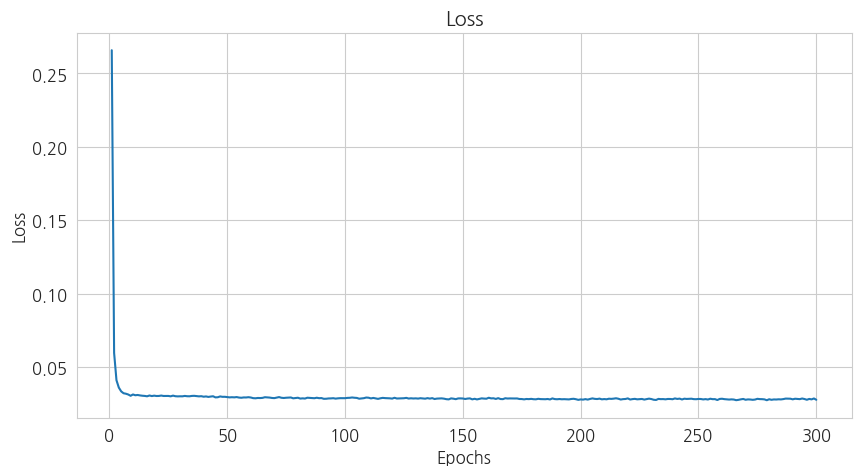

In [21]:
plt.figure(figsize=(10, 5), dpi=100)
sns.lineplot(data=df_metrics, x="epochs", y="loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Loss")
plt.show()

## Recall & Precision

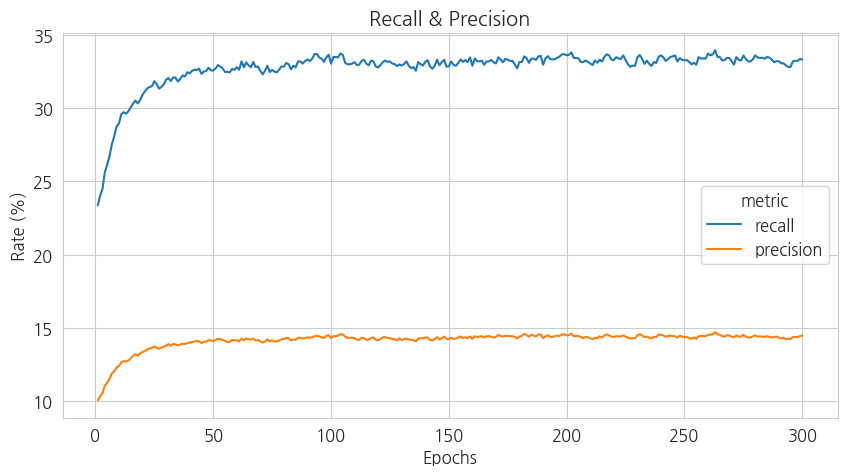

In [22]:
plt.figure(figsize=(10, 5), dpi=100)

# Recall & Precision을 하나의 컬럼으로 변환
df_recall_precision = df_metrics[["epochs", "recall", "precision"]].melt(
    id_vars="epochs", var_name="metric", value_name="value"
)
df_recall_precision["value"] = df_recall_precision["value"] * 100

sns.lineplot(data=df_recall_precision, x="epochs", y="value", hue="metric")
plt.xlabel("Epochs")
plt.ylabel("Rate (%)")
plt.title("Recall & Precision")
plt.show()

# Embedding Vectors

In [23]:
# 임베딩 벡터 조회
df_user_vectors = pd.read_parquet(save_path.joinpath("user_vector.parquet"))
df_item_vectors = pd.read_parquet(save_path.joinpath("item_vector.parquet"))

# 벡터(Numpy 배열) 변환
user_vectors = np.array(df_user_vectors["vector_normalized"].tolist())
item_vectors = np.array(df_item_vectors["vector_normalized"].tolist())

## User Vectors

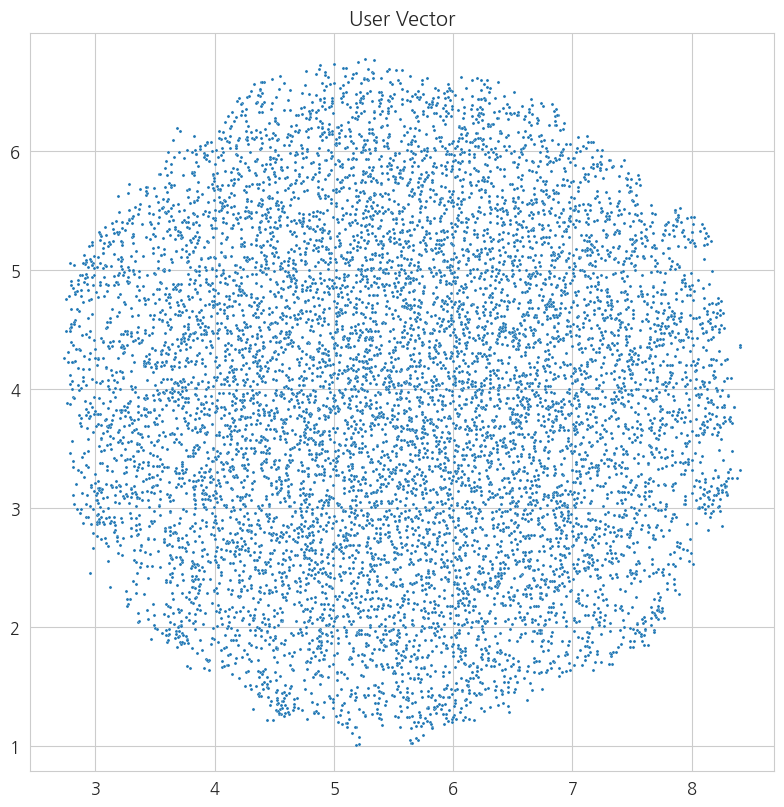

In [24]:
# UMAP 기반 차원 축소
# - metric="cosine": 임베딩 간 코사인 거리 기준으로 구조를 보존
reducer = umap.UMAP(metric="cosine")

# 벡터 차원 축소 (예: 64차원 -> 2차원)
embeddings = reducer.fit_transform(user_vectors)

plt.figure(figsize=(8, 8))

# UMAP 결과를 산점도로 표현
# - x축: 축소된 첫 번째 차원
# - y축: 축소된 두 번째 차원
# - s=5: 점 크기 (작게)
# - legend=False: 범례 제거
sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], s=5, legend=False)

# 축 비율을 동일하게 설정 (왜곡 방지)
plt.gca().set_aspect("equal", "datalim")

# 여백 자동 조정
plt.tight_layout()

plt.title("User Vector")
plt.show()

## Item Vectors

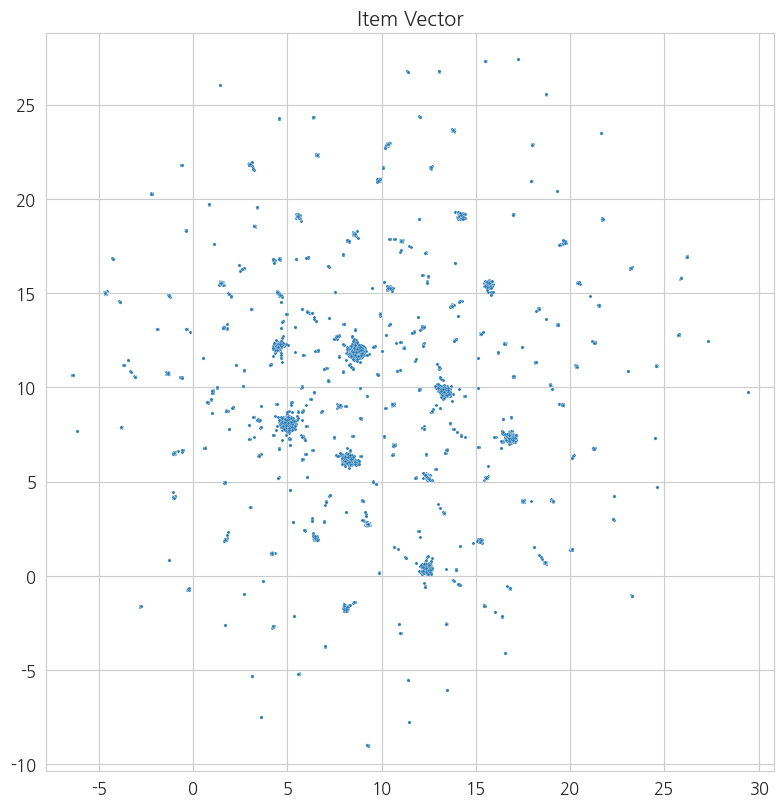

In [25]:
# UMAP 기반 차원 축소
# - metric="cosine": 임베딩 간 코사인 거리 기준으로 구조를 보존
reducer = umap.UMAP(metric="cosine")

# 벡터 차원 축소 (예: 64차원 -> 2차원)
embeddings = reducer.fit_transform(item_vectors)

plt.figure(figsize=(8, 8))

# UMAP 결과를 산점도로 표현
# - x축: 축소된 첫 번째 차원
# - y축: 축소된 두 번째 차원
# - s=5: 점 크기 (작게)
# - legend=False: 범례 제거
sns.scatterplot(x=embeddings[:, 0], y=embeddings[:, 1], s=5, legend=False)

# 축 비율을 동일하게 설정 (왜곡 방지)
plt.gca().set_aspect("equal", "datalim")

# 여백 자동 조정
plt.tight_layout()

plt.title("Item Vector")
plt.show()

## User & Item Vectors

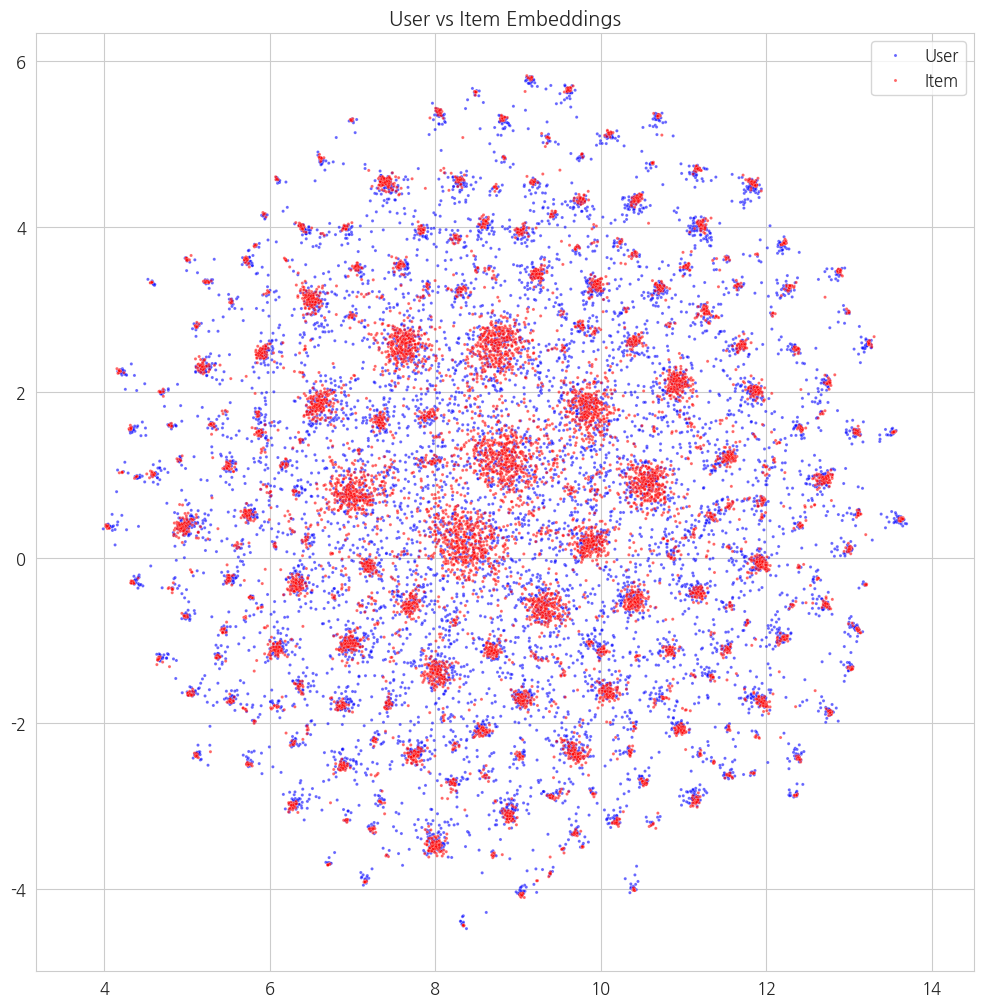

In [26]:
# 유저 & 아이템 벡터 합치기
all_vectors = np.vstack([user_vectors, item_vectors])
# User, Item 범례 구분 값(User/Item)
labels = ["User"] * len(user_vectors) + ["Item"] * len(item_vectors)

# UMAP 기반 차원 축소
# - metric="cosine": 임베딩 간 코사인 거리 기준으로 구조를 보존
reducer = umap.UMAP(metric="cosine")
embeddings = reducer.fit_transform(all_vectors)

plt.figure(figsize=(10, 10))

sns.scatterplot(
    x=embeddings[:, 0],
    y=embeddings[:, 1],
    hue=labels,  # User vs Item 색상 구분
    palette={"User": "blue", "Item": "red"},
    s=5,
    alpha=0.6,
    legend="full",
)

plt.gca().set_aspect("equal", "datalim")
plt.tight_layout()
plt.title("User vs Item Embeddings")
plt.show()

# 가까운 위치에 있는 유저와 아이템은 추천 후보군 가능성이 높음
# 군집(cluster) 패턴을 보면 특정 취향 그룹과 아이템 카테고리가 어떻게 매칭되는지 직관적으로 확인 가능

In [27]:
import plotly.express as px

# 유저 & 아이템 벡터 합치기
all_vectors = np.vstack([user_vectors, item_vectors])
# User, Item 범례 구분 값(User & Item)
labels = ["User"] * len(user_vectors) + ["Item"] * len(item_vectors)

ids = [f"User_{i}" for i in range(len(user_vectors))] + [
    f"Item_{j}" for j in range(len(item_vectors))
]

# UMAP 기반 차원 축소
# - metric="cosine": 임베딩 간 코사인 거리 기준으로 구조를 보존
reducer = umap.UMAP(metric="cosine")
embeddings = reducer.fit_transform(all_vectors)

# DataFrame 생성
df_plot = pd.DataFrame(
    {"x": embeddings[:, 0], "y": embeddings[:, 1], "label": labels, "id": ids}
)

# Plotly 시각화
fig = px.scatter(
    df_plot,
    x="x",
    y="y",
    color="label",
    hover_data=["id"],  # 마우스 오버 시 ID 표시
    opacity=0.7,
    title="User vs Item Embeddings",
)

fig.update_traces(marker=dict(size=6))
fig.show()